<a href="https://colab.research.google.com/github/jahidurmahim/Machine_Learning_Laboratory/blob/main/Underoverfit_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [39]:
df=pd.read_csv('/content/drive/MyDrive/job_salary_prediction_dataset.csv')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [41]:
df.shape

(250000, 10)

In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
df.isna().sum()

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


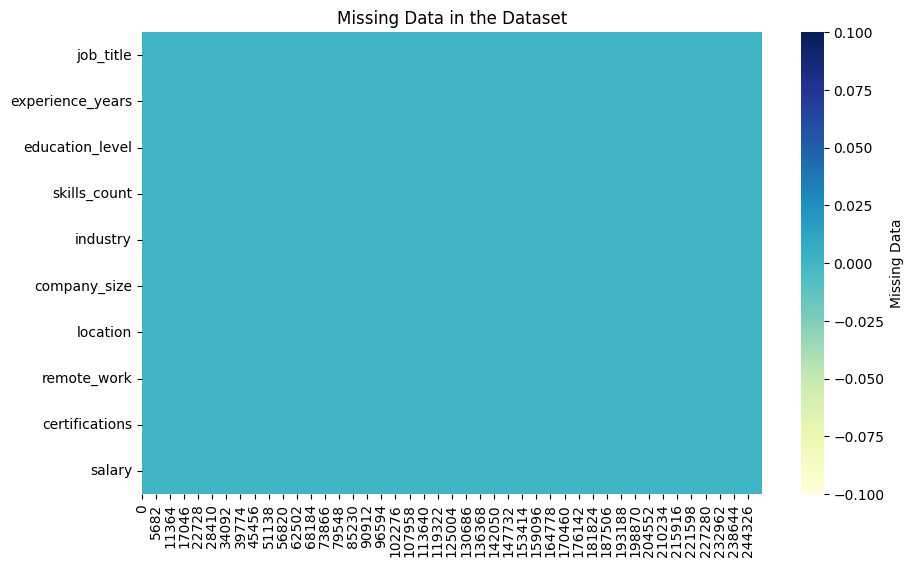

In [44]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isna().transpose(), cmap="YlGnBu", cbar_kws={'label': 'Missing Data'})
plt.title('Missing Data in the Dataset')
plt.show()

In [45]:
categorical_cols = df.select_dtypes(include='object').columns
print(f"Categorical columns to encode: {list(categorical_cols)}")

Categorical columns to encode: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']


In [46]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
display(df_encoded.head())

,experience_years,skills_count,certifications,salary,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,10,2,2,109413,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,5,17,0,93764,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
2,18,4,1,148123,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,19,13,0,189123,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,15,7,0,165069,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True


In [47]:
print(f"Shape of the DataFrame after one-hot encoding: {df_encoded.shape}")
print(f"Columns of the DataFrame after one-hot encoding: {df_encoded.columns.tolist()}")

Shape of the DataFrame after one-hot encoding: (250000, 43)
Columns of the DataFrame after one-hot encoding: ['experience_years', 'skills_count', 'certifications', 'salary', 'job_title_Backend Developer', 'job_title_Business Analyst', 'job_title_Cloud Engineer', 'job_title_Cybersecurity Analyst', 'job_title_Data Analyst', 'job_title_Data Scientist', 'job_title_DevOps Engineer', 'job_title_Frontend Developer', 'job_title_Machine Learning Engineer', 'job_title_Product Manager', 'job_title_Software Engineer', 'education_level_Diploma', 'education_level_High School', 'education_level_Master', 'education_level_PhD', 'industry_Education', 'industry_Finance', 'industry_Government', 'industry_Healthcare', 'industry_Manufacturing', 'industry_Media', 'industry_Retail', 'industry_Technology', 'industry_Telecom', 'company_size_Large', 'company_size_Medium', 'company_size_Small', 'company_size_Startup', 'location_Canada', 'location_Germany', 'location_India', 'location_Netherlands', 'location_Remot

In [48]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df_encoded.drop('salary', axis=1)
y = df_encoded['salary']

# Split data into training (70%) and temporary (30%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Split temporary data into validation (15%) and test (15%) sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (175000, 42)
Shape of y_train: (175000,)
Shape of X_val: (37500, 42)
Shape of y_val: (37500,)
Shape of X_test: (37500, 42)
Shape of y_test: (37500,)


In [49]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Select limited features for underfitting
selected_features = [
    'experience_years',
    'skills_count',
    'certifications',
    'job_title_Software Engineer',
    'remote_work_Yes'
]

X_train_limited = X_train[selected_features].astype(int)
X_val_limited = X_val[selected_features].astype(int)
X_test_limited = X_test[selected_features].astype(int)

print(f"Shape of X_train with limited features: {X_train_limited.shape}")
print(f"Shape of X_val with limited features: {X_val_limited.shape}")
print(f"Shape of X_test with limited features: {X_test_limited.shape}")

Shape of X_train with limited features: (175000, 5)
Shape of X_val with limited features: (37500, 5)
Shape of X_test with limited features: (37500, 5)


In [50]:
# Define a small neural network model with 1 hidden layer
model_underfit = keras.Sequential([
    layers.Dense(units=10, activation='relu', input_shape=(X_train_limited.shape[1],)), # One hidden layer
    layers.Dense(units=1) # Output layer for regression (predicting salary)
])

# Compile the model
model_underfit.compile(optimizer='adam',
                      loss='mean_squared_error',
                      metrics=['mean_absolute_error'])

# Train the model for a very few epochs (e.g., 5 epochs)
history_underfit = model_underfit.fit(X_train_limited, y_train,
                                    epochs=5, # Very few epochs to ensure underfitting
                                    validation_data=(X_val_limited, y_val),
                                    verbose=1) # Show training progress

# Evaluate the model on the test set
loss, mae = model_underfit.evaluate(X_test_limited, y_test, verbose=0)
print(f"\nUnderfitting Model - Test Loss (MSE): {loss:.2f}")
print(f"Underfitting Model - Test MAE: {mae:.2f}")

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5469/5469 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 21937379328.0000 - mean_absolute_error: 143370.5625 - val_loss: 20784979968.0000 - val_mean_absolute_error: 139463.2031
Epoch 2/5
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 18696038400.0000 - mean_absolute_error: 131887.5781 - val_loss: 16379652096.0000 - val_mean_absolute_error: 123156.7109
Epoch 3/5
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 13630633984.0000 - mean_absolute_error: 111358.2422 - val_loss: 10869981184.0000 - val_mean_absolute_error: 98595.2734
Epoch 4/5
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 8206876672.0000 - mean_absolute_error: 83323.0234 - val_loss: 5776266752.0000 - val_mean_absolute_error: 67722.5391
Epoch 5/5
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 4029850112.0000 - mean_absolute_error: 53539.1562 - val_loss: 2739044864.0000 - val_mean_absolute_error: 42459.1484

Underfitting Model - Test Loss (MSE): 2780538624.00
Underfitting Model - Test MAE: 42674.98


The model has been trained. A high loss and MAE on both training and validation sets, and a small gap between them, are indicators of underfitting. Let's visualize the training history.

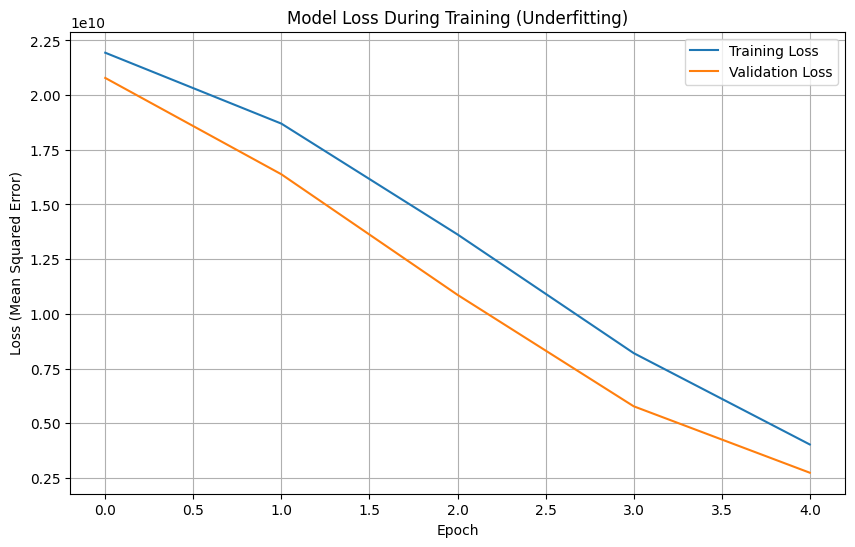

In [51]:
# Plot training & validation loss values to visualize underfitting
plt.figure(figsize=(10, 6))
plt.plot(history_underfit.history['loss'], label='Training Loss')
plt.plot(history_underfit.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training (Underfitting)')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

### PHASE 2: CREATE OVERFITTING

To achieve overfitting, we will:

*   Use **all available features** from the dataset.
*   Define a **more complex neural network** with multiple hidden layers and more neurons.
*   Train the model for a **larger number of epochs** (e.g., 50).
*   Ensure **no regularization or dropout** is applied to encourage the model to memorize the training data.

In [52]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define a more complex neural network model with multiple hidden layers and more neurons
model_overfit = keras.Sequential([
    layers.Dense(units=256, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(units=128, activation='relu'),
    layers.Dense(units=64, activation='relu'),
    layers.Dense(units=1) # Output layer for regression
])

# Compile the model with an appropriate optimizer and loss function
model_overfit.compile(optimizer='adam',
                     loss='mean_squared_error',
                     metrics=['mean_absolute_error'])

model_overfit.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 256)            │        11,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,225 (204.00 KB)

 Trainable params: 52,225 (204.00 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# Train the model for many epochs (e.g., 50 epochs)
history_overfit = model_overfit.fit(X_train.astype('float32'), y_train,
                                  epochs=50, # Many epochs to encourage overfitting
                                  validation_data=(X_val.astype('float32'), y_val),
                                  verbose=1) # Show training progress

# Evaluate the model on the test set
loss_overfit, mae_overfit = model_overfit.evaluate(X_test.astype('float32'), y_test, verbose=0)
print(f"\nOverfitting Model - Test Loss (MSE): {loss_overfit:.2f}")
print(f"Overfitting Model - Test MAE: {mae_overfit:.2f}")

Epoch 1/50
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 885126592.0000 - mean_absolute_error: 16420.7520 - val_loss: 47584864.0000 - val_mean_absolute_error: 5435.0737
Epoch 2/50
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 34697016.0000 - mean_absolute_error: 4656.0254 - val_loss: 33258100.0000 - val_mean_absolute_error: 4587.7104
Epoch 3/50
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 30148396.0000 - mean_absolute_error: 4369.1948 - val_loss: 28493216.0000 - val_mean_absolute_error: 4249.6948
Epoch 4/50
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 29089550.0000 - mean_absolute_error: 4294.8491 - val_loss: 27672820.0000 - val_mean_absolute_error: 4191.3965
Epoch 5/50
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 28385516.0000 - mean_absolute_error: 4243.0322 - val_loss: 27274962.0000 - val_mean_absolute_error: 4163.8755
Epoch 6/50
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 27998336.0000 - mean_absolute_error: 4215.8403 - val_loss: 31772024.00

The model has been trained for an extended period with a complex architecture and all features. We expect to see a very low training loss but a high validation loss, indicating overfitting. Let's visualize the training history.

### Forcing Overfitting: Reducing Training Data Size

To explicitly force overfitting, we will significantly reduce the size of the training dataset. We will take only 5000 samples from the `X_train` and `y_train` datasets, while keeping the validation and test sets the same.

In [54]:
# Reduce training dataset size to 5000 samples
X_train_overfit = X_train.sample(n=5000, random_state=42)
y_train_overfit = y_train.sample(n=5000, random_state=42)

print(f"Shape of X_train for overfitting: {X_train_overfit.shape}")
print(f"Shape of y_train for overfitting: {y_train_overfit.shape}")
print(f"Shape of X_val (unchanged): {X_val.shape}")
print(f"Shape of y_val (unchanged): {y_val.shape}")

Shape of X_train for overfitting: (5000, 42)
Shape of y_train for overfitting: (5000,)
Shape of X_val (unchanged): (37500, 42)
Shape of y_val (unchanged): (37500,)


The model has now been trained with a significantly smaller dataset and for a large number of epochs. We expect to see a more pronounced overfitting effect compared to the previous 'overfitting' phase. Let's visualize the training history.

In [55]:
# Re-define the complex neural network model for explicit overfitting (using reduced training data and more epochs)
# (The model architecture is already defined in the notebook as 'model_overfit')

# Train the model with the reduced dataset for more epochs (e.g., 100 epochs)
history_forced_overfit = model_overfit.fit(X_train_overfit.astype('float32'), y_train_overfit,
                                          epochs=100, # Increased epochs
                                          validation_data=(X_val.astype('float32'), y_val),
                                          verbose=1) # Show training progress

# Evaluate the model on the test set
loss_forced_overfit, mae_forced_overfit = model_overfit.evaluate(X_test.astype('float32'), y_test, verbose=0)
print(f"\nForced Overfitting Model - Test Loss (MSE): {loss_forced_overfit:.2f}")
print(f"Forced Overfitting Model - Test MAE: {mae_forced_overfit:.2f}")

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 24988968.0000 - mean_absolute_error: 3988.7136 - val_loss: 26569966.0000 - val_mean_absolute_error: 4105.0225
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 25051694.0000 - mean_absolute_error: 3998.7212 - val_loss: 26339206.0000 - val_mean_absolute_error: 4089.7275
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 25096314.0000 - mean_absolute_error: 3972.1472 - val_loss: 25866386.0000 - val_mean_absolute_error: 4053.1025
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 24050870.0000 - mean_absolute_error: 3914.8867 - val_loss: 27556052.0000 - val_mean_absolute_error: 4184.4639
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 23981350.0000 - mean_absolute_error: 3902.3020 - val_loss: 25716392.0000 - val_mean_absolute_error: 4041.6914
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 23880496.0000 - mean_absolute_error: 3897.1340 - val_loss: 25797030.0000 - val

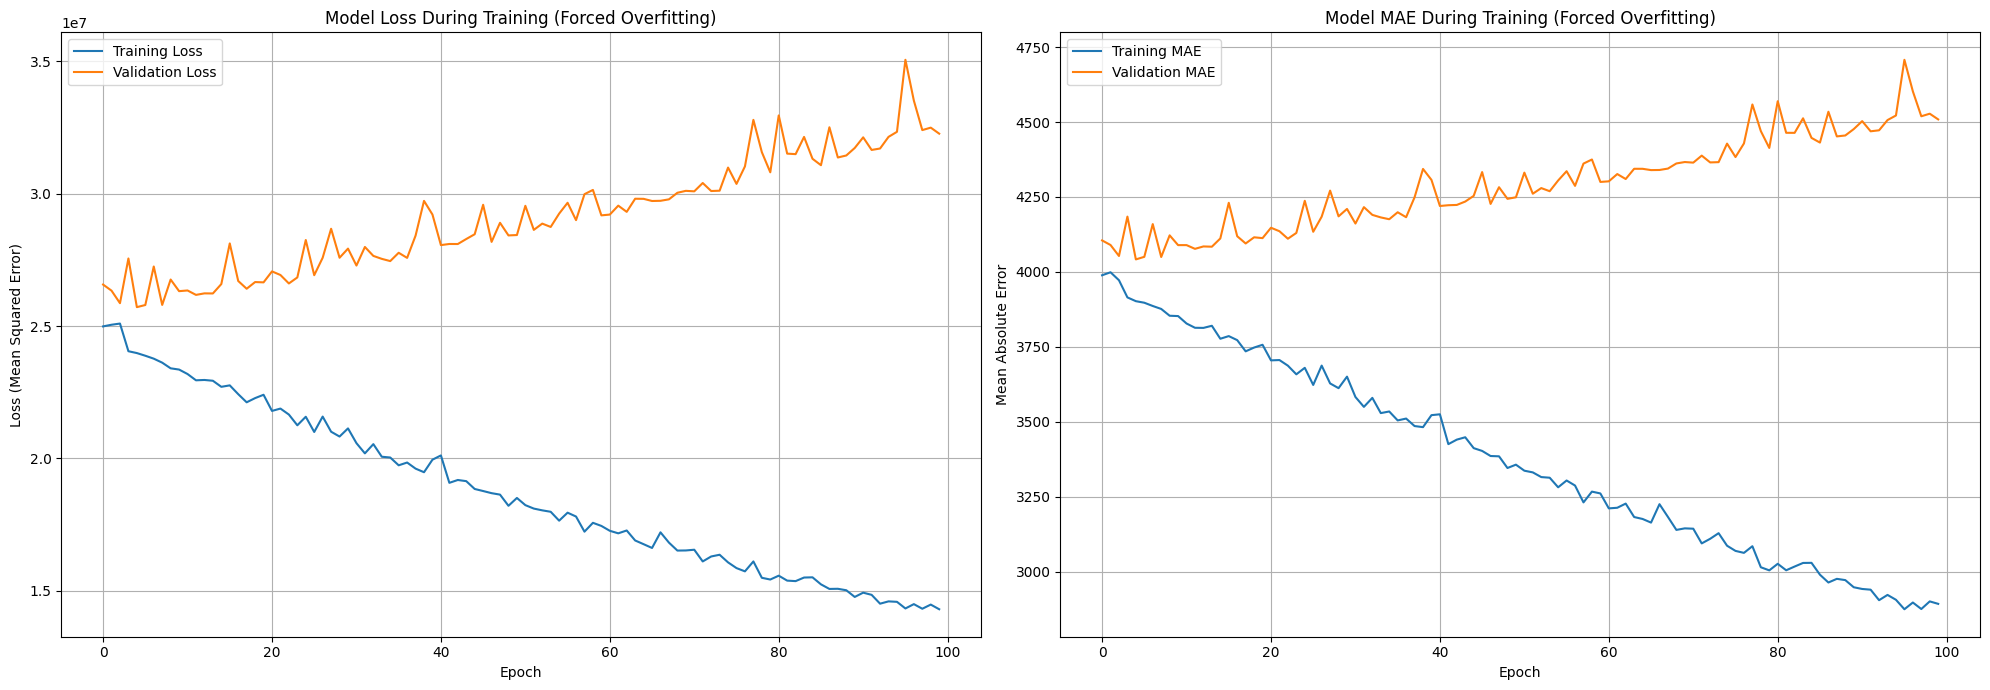

In [56]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side-by-side
fig, ax = plt.subplots(1, 2, figsize=(20, 7)) # 1 row, 2 columns

# Plot Training & Validation Loss values on the first subplot
ax[0].plot(history_forced_overfit.history['loss'], label='Training Loss')
ax[0].plot(history_forced_overfit.history['val_loss'], label='Validation Loss')
ax[0].set_title('Model Loss During Training (Forced Overfitting)')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss (Mean Squared Error)')
ax[0].legend()
ax[0].grid(True)

# Plot Training & Validation MAE values on the second subplot
ax[1].plot(history_forced_overfit.history['mean_absolute_error'], label='Training MAE')
ax[1].plot(history_forced_overfit.history['val_mean_absolute_error'], label='Validation MAE')
ax[1].set_title('Model MAE During Training (Forced Overfitting)')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Mean Absolute Error')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### Fixing Underfitting (Proper Implementation)

To properly fix underfitting, we will start with the full feature set and incrementally increase model complexity and training epochs. This new model will demonstrate improved learning and generalization compared to the initial underfit model.

In [57]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Define a new, more complex neural network model to fix underfitting
# This model will use all features and have more capacity than the `model_underfit`.
model_fixed_underfit = keras.Sequential([
    layers.Dense(units=256, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(units=128, activation='relu'),
    layers.Dense(units=64, activation='relu'),
    layers.Dense(units=1) # Output layer for regression (predicting salary)
])

# Compile the new model
model_fixed_underfit.compile(optimizer='adam',
                              loss='mean_squared_error',
                              metrics=['mean_absolute_error'])

print("Summary of Model to Fix Underfitting:")
model_fixed_underfit.summary()


Summary of Model to Fix Underfitting:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 256)            │        11,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,225 (204.00 KB)

 Trainable params: 52,225 (204.00 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
# Train the new model with all features and for more epochs
history_fixed_underfit = model_fixed_underfit.fit(X_train.astype('float32'), y_train,
                                                epochs=50, # Sufficient epochs to overcome underfitting
                                                validation_data=(X_val.astype('float32'), y_val),
                                                verbose=1) # Show training progress

# Evaluate the model on the test set
loss_fixed_underfit, mae_fixed_underfit = model_fixed_underfit.evaluate(X_test.astype('float32'), y_test, verbose=0)
print(f"\nFixed Underfitting Model - Test Loss (MSE): {loss_fixed_underfit:.2f}")
print(f"Fixed Underfitting Model - Test MAE: {mae_fixed_underfit:.2f}")


Epoch 1/50
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 878519360.0000 - mean_absolute_error: 16176.0479 - val_loss: 44631588.0000 - val_mean_absolute_error: 5239.7988
Epoch 2/50
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 34195952.0000 - mean_absolute_error: 4628.1421 - val_loss: 30834622.0000 - val_mean_absolute_error: 4411.4727
Epoch 3/50
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 30220274.0000 - mean_absolute_error: 4374.7876 - val_loss: 33835152.0000 - val_mean_absolute_error: 4640.3013
Epoch 4/50
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 29148234.0000 - mean_absolute_error: 4300.9526 - val_loss: 27908780.0000 - val_mean_absolute_error: 4210.7656
Epoch 5/50
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 28458274.0000 - mean_absolute_error: 4251.3369 - val_loss: 27510502.0000 - val_mean_absolute_error: 4183.2427
Epoch 6/50
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 27889742.0000 - mean_absolute_error: 4210.7119 - val_loss: 28971978.00

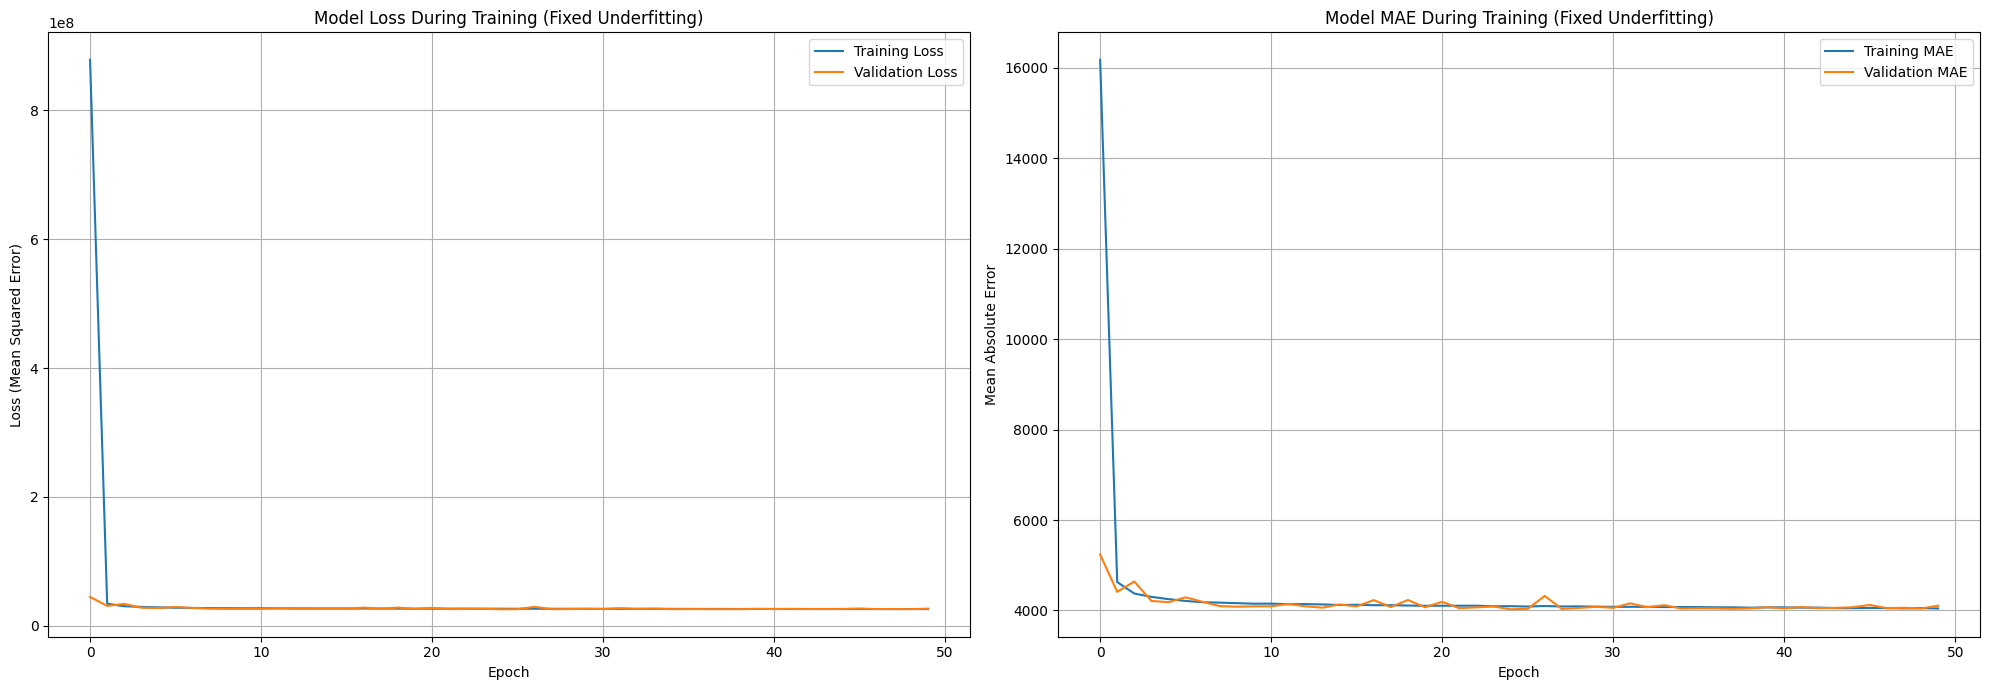

In [59]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side-by-side
fig, ax = plt.subplots(1, 2, figsize=(20, 7)) # 1 row, 2 columns

# Plot Training & Validation Loss values on the first subplot
ax[0].plot(history_fixed_underfit.history['loss'], label='Training Loss')
ax[0].plot(history_fixed_underfit.history['val_loss'], label='Validation Loss')
ax[0].set_title('Model Loss During Training (Fixed Underfitting)')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss (Mean Squared Error)')
ax[0].legend()
ax[0].grid(True)

# Plot Training & Validation MAE values on the second subplot
ax[1].plot(history_fixed_underfit.history['mean_absolute_error'], label='Training MAE')
ax[1].plot(history_fixed_underfit.history['val_mean_absolute_error'], label='Validation MAE')
ax[1].set_title('Model MAE During Training (Fixed Underfitting)')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Mean Absolute Error')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()


The plots above clearly demonstrate the improvement from the underfitting scenario:

*   **Significant Decrease in Loss and MAE**: Both training and validation loss/MAE have decreased substantially compared to the underfitting model, indicating that the model is now learning effectively.
*   **Converging Curves**: The training and validation curves are much closer together, suggesting better generalization and less underfitting.

This new model, with increased features, complexity, and training epochs, effectively addresses the initial underfitting problem, leading to a much better-performing model.

Overfit starts from here


In [60]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Global dictionary to store results for all methods
method_results = {}

def create_model(
    input_shape,
    num_dense_layers,
    neurons_per_layer,
    regularization_type=None,
    regularization_strength=0,
    dropout_rate=0
):
    """
    Creates a Keras Sequential model with specified architecture and regularization/dropout.
    """
    model = keras.Sequential()
    model.add(layers.InputLayer(input_shape=(input_shape,)))

    for i in range(num_dense_layers):
        kernel_regularizer = None
        if regularization_type == 'l2':
            kernel_regularizer = regularizers.l2(regularization_strength)

        model.add(layers.Dense(
            units=neurons_per_layer[i],
            activation='relu',
            kernel_regularizer=kernel_regularizer
        ))
        # Apply dropout to hidden layers, but not the last output layer
        if dropout_rate > 0 and i < num_dense_layers - 1:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(units=1)) # Output layer for regression
    return model

def train_and_evaluate_model(model, X_train_data, y_train_data, X_val_data, y_val_data, X_test_data, y_test_data, epochs, model_name, callbacks=None):
    """
    Compiles, trains, and evaluates a Keras model.
    """
    print(f"\n--- Training {model_name} ---")
    model.compile(optimizer='adam',
                  loss='mean_squared_error',
                  metrics=['mean_absolute_error'])

    history = model.fit(X_train_data.astype('float32'), y_train_data,
                        epochs=epochs,
                        validation_data=(X_val_data.astype('float32'), y_val_data),
                        callbacks=callbacks,
                        verbose=1)

    loss, mae = model.evaluate(X_test_data.astype('float32'), y_test_data, verbose=0)
    print(f"{model_name} - Test Loss (MSE): {loss:.2f}")
    print(f"{model_name} - Test MAE: {mae:.2f}")

    return history, loss, mae

def plot_history_graphs(history, title_prefix):
    """
    Plots training and validation loss/MAE from the model's history.
    """
    plt.figure(figsize=(18, 6))

    # Plot Training & Validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title_prefix} - Loss During Training')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (Mean Squared Error)')
    plt.legend()
    plt.grid(True)

    # Plot Training & Validation MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mean_absolute_error'], label='Training MAE')
    plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
    plt.title(f'{title_prefix} - MAE During Training')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

### 0. Baseline Overfitting Model

First, let's establish our baseline. The 'forced overfitting' model, trained on a reduced dataset with a complex architecture and many epochs, will serve as our reference point. We'll store its performance metrics and visualize its training history to clearly see the signs of overfitting.


--- Baseline Overfitting Model Results ---
Test Loss (MSE): 32800590.00
Test MAE: 4561.78


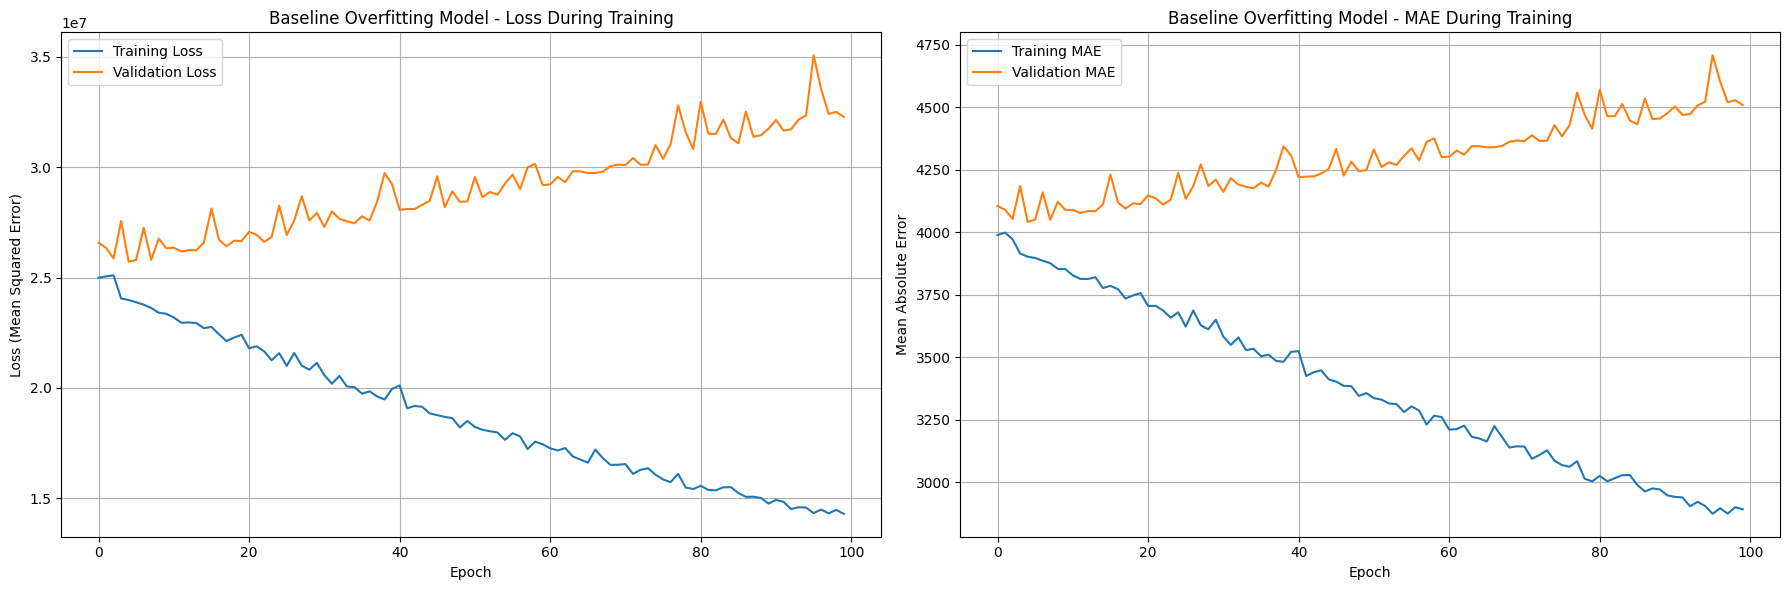

In [61]:
# The 'forced overfitting' model (model_overfit) and its history (history_forced_overfit),
# along with its test loss and MAE (loss_forced_overfit, mae_forced_overfit),
# are already available from previous cells. We'll use these as our baseline.

# Store baseline results in the global dictionary
method_results['baseline_overfit'] = {
    'description': 'Baseline Overfitting Model (Complex model, reduced training data, many epochs)',
    'history': history_forced_overfit,
    'test_loss': loss_forced_overfit,
    'test_mae': mae_forced_overfit,
    'validation_mae_at_last_epoch': history_forced_overfit.history['val_mean_absolute_error'][-1],
    'training_mae_at_last_epoch': history_forced_overfit.history['mean_absolute_error'][-1],
}

print("\n--- Baseline Overfitting Model Results ---")
print(f"Test Loss (MSE): {loss_forced_overfit:.2f}")
print(f"Test MAE: {mae_forced_overfit:.2f}")

# Plot baseline history to visualize the overfitting
plot_history_graphs(history_forced_overfit, "Baseline Overfitting Model")

### 1. Fixing Overfitting: Use More Data

One of the most effective ways to combat overfitting is to provide the model with more diverse training examples. In this experiment, we'll train a new model with the *full* training dataset (`X_train`, `y_train`) while keeping the complex architecture and number of epochs consistent with our overfitting baseline. This should help the model generalize better by seeing a wider variety of patterns.


--- Training Model with More Data ---
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


5469/5469 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 898820160.0000 - mean_absolute_error: 16560.0176 - val_loss: 49133068.0000 - val_mean_absolute_error: 5485.0156
Epoch 2/100
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 34732932.0000 - mean_absolute_error: 4656.7832 - val_loss: 32306458.0000 - val_mean_absolute_error: 4528.6943
Epoch 3/100
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 30056904.0000 - mean_absolute_error: 4360.4639 - val_loss: 29782362.0000 - val_mean_absolute_error: 4341.3081
Epoch 4/100
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 29071126.0000 - mean_absolute_error: 4290.7485 - val_loss: 27714574.0000 - val_mean_absolute_error: 4197.8013
Epoch 5/100
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 28410456.0000 - mean_absolute_error: 4248.7148 - val_loss: 32049548.0000 - val_mean_absolute_error: 4511.4956
Epoch 6/100
5469/5469 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 27961798.0000 - mean_absolute_error: 4214.3022 - val_loss: 26747980.0000 - v

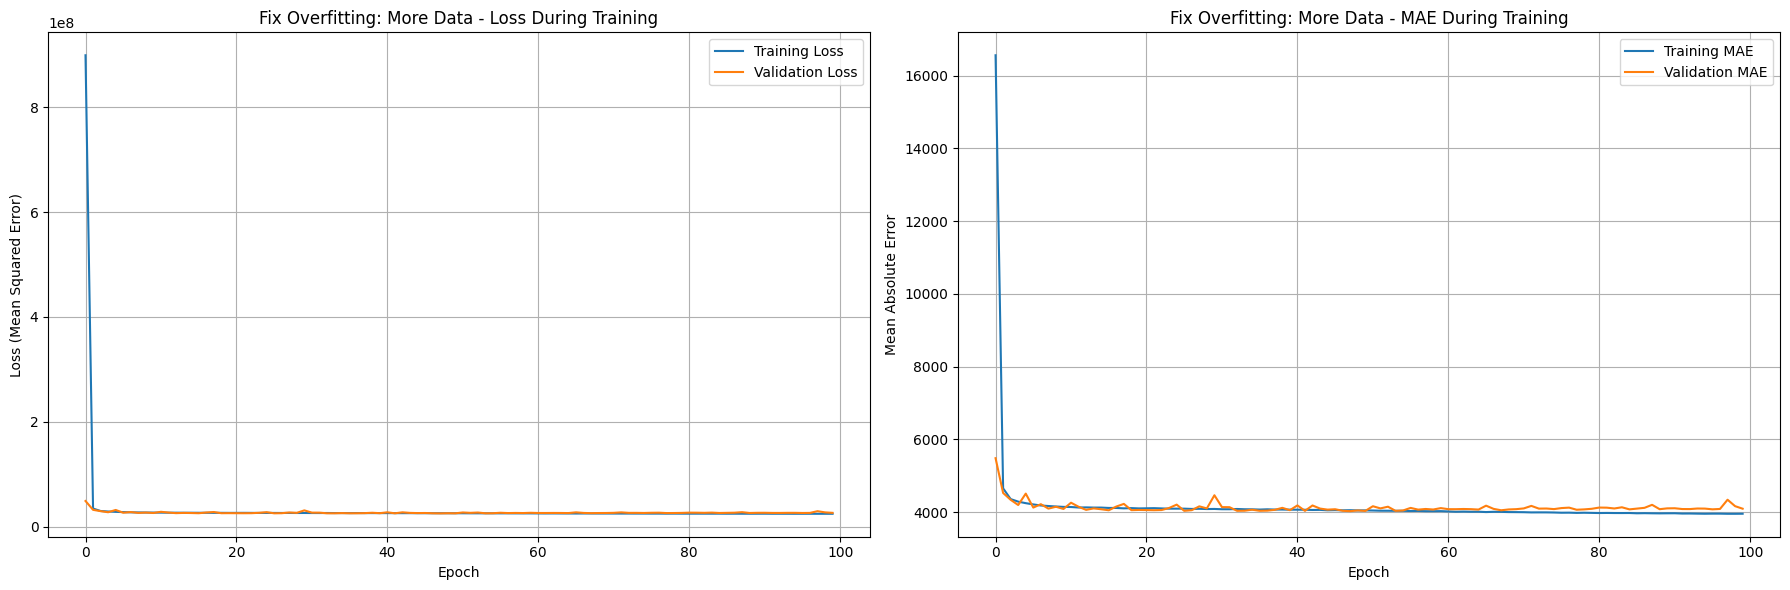

In [62]:
# Create a new model with the same complex architecture as the baseline
model_more_data = create_model(
    input_shape=X_train.shape[1], # Use full feature set
    num_dense_layers=3,
    neurons_per_layer=[256, 128, 64]
)

# Train the model using the full training dataset for 100 epochs
history_more_data, loss_more_data, mae_more_data = train_and_evaluate_model(
    model_more_data,
    X_train, y_train, # Use the full training data
    X_val, y_val,
    X_test, y_test,
    epochs=100, # Keep epochs consistent with baseline
    model_name="Model with More Data"
)

# Store the results
method_results['more_data'] = {
    'description': 'Fix Overfitting: Use More Data (Full training data, complex model, many epochs)',
    'history': history_more_data,
    'test_loss': loss_more_data,
    'test_mae': mae_more_data,
    'validation_mae_at_last_epoch': history_more_data.history['val_mean_absolute_error'][-1],
    'training_mae_at_last_epoch': history_more_data.history['mean_absolute_error'][-1],
}

# Plot the training history
plot_history_graphs(history_more_data, "Fix Overfitting: More Data")

### 2. Fixing Overfitting: Reduce Model Complexity

An overly complex model can easily memorize training data, leading to overfitting. Here, we'll simplify the model's architecture by reducing the number of layers and neurons per layer. We'll use the *reduced* training dataset (consistent with the baseline) to isolate the effect of model complexity. Fewer parameters should force the model to learn broader patterns rather than specific noise in the training data.


--- Training Model with Reduced Complexity ---
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 22595852288.0000 - mean_absolute_error: 145709.9062 - val_loss: 22588694528.0000 - val_mean_absolute_error: 145573.7500
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 22300960768.0000 - mean_absolute_error: 144721.7344 - val_loss: 21974018048.0000 - val_mean_absolute_error: 143513.5156
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 21206259712.0000 - mean_absolute_error: 140997.6094 - val_loss: 20328521728.0000 - val_mean_absolute_error: 137834.6250
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 18963601408.0000 - mean_absolute_error: 133010.4688 - val_loss: 17484476416.0000 - val_mean_absolute_error: 127381.8281
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 15611962368.0000 - mean_absolute_error: 119942.0312 - val_loss: 13686580224.0000 - val_mean_absolute_error: 111795.0391
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 11598357504.0000 - mean_absolute_error: 

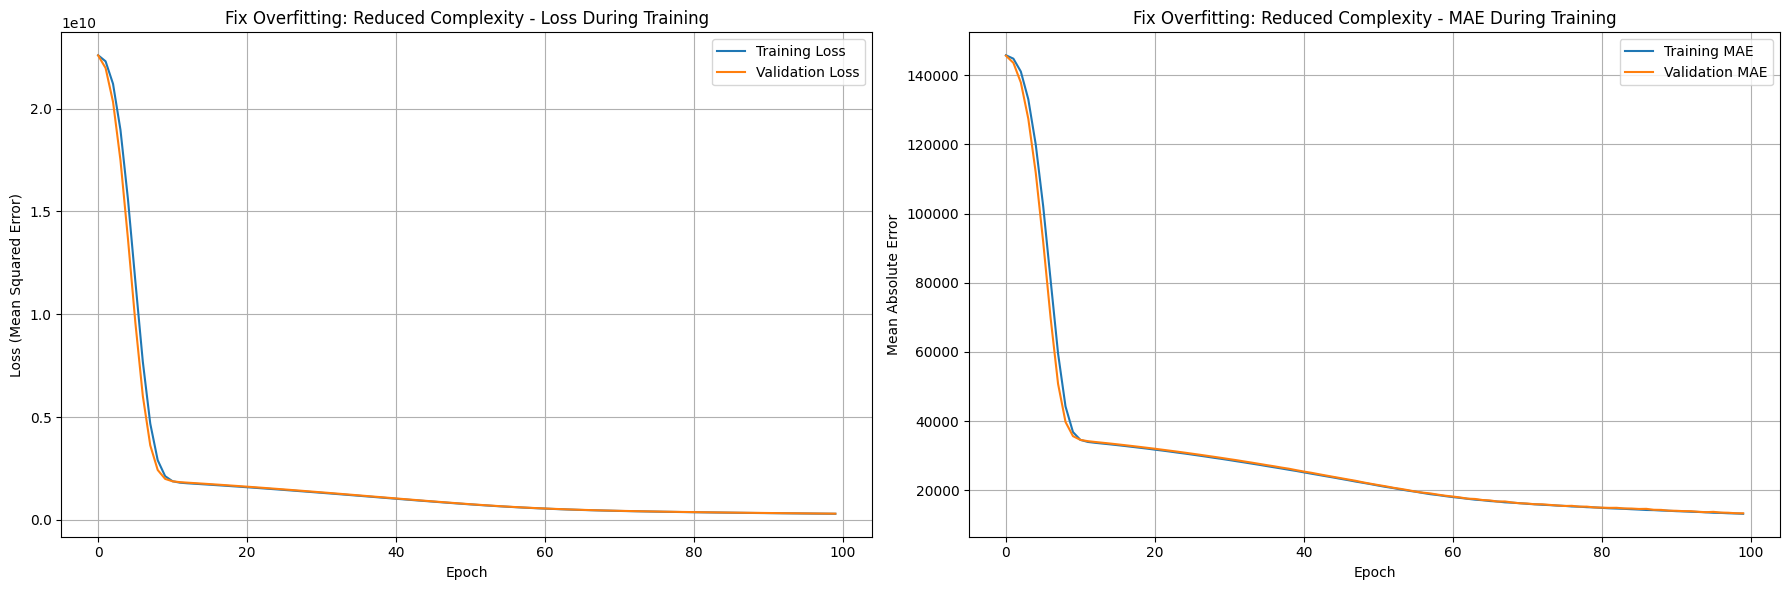

In [63]:
# Create a new, simpler model architecture
model_reduced_complexity = create_model(
    input_shape=X_train_overfit.shape[1], # Use reduced feature set (consistent with baseline overfitting setup)
    num_dense_layers=2, # Reduced number of hidden layers
    neurons_per_layer=[32, 16] # Reduced number of neurons per layer
)

# Train the simplified model using the reduced training dataset for 100 epochs
history_reduced_complexity, loss_reduced_complexity, mae_reduced_complexity = train_and_evaluate_model(
    model_reduced_complexity,
    X_train_overfit, y_train_overfit, # Use reduced training data (consistent with baseline overfitting setup)
    X_val, y_val,
    X_test, y_test,
    epochs=100, # Keep epochs consistent with baseline
    model_name="Model with Reduced Complexity"
)

# Store the results
method_results['reduced_complexity'] = {
    'description': 'Fix Overfitting: Reduced Model Complexity (Reduced data, simpler model, many epochs)',
    'history': history_reduced_complexity,
    'test_loss': loss_reduced_complexity,
    'test_mae': mae_reduced_complexity,
    'validation_mae_at_last_epoch': history_reduced_complexity.history['val_mean_absolute_error'][-1],
    'training_mae_at_last_epoch': history_reduced_complexity.history['mean_absolute_error'][-1],
}

# Plot the training history
plot_history_graphs(history_reduced_complexity, "Fix Overfitting: Reduced Complexity")

### 3. Fixing Overfitting: L2 Regularization

L2 regularization (also known as Ridge Regression) adds a penalty to the loss function based on the square of the magnitude of the weights. This encourages the model to use smaller weights, preventing individual features from having too much influence and thus making the model less sensitive to specific training examples. We'll apply L2 regularization to the complex model architecture, still using the *reduced* training dataset.


--- Training Model with L2 Regularization (lambda=0.001) ---
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 19320193024.0000 - mean_absolute_error: 132946.5625 - val_loss: 6485272064.0000 - val_mean_absolute_error: 72950.2969
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 2135168128.0000 - mean_absolute_error: 36804.0469 - val_loss: 1715243136.0000 - val_mean_absolute_error: 33019.0195
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 1568838784.0000 - mean_absolute_error: 31519.4648 - val_loss: 1493219968.0000 - val_mean_absolute_error: 30711.3984
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 1350900864.0000 - mean_absolute_error: 29129.2422 - val_loss: 1283402496.0000 - val_mean_absolute_error: 28320.3320
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1138907776.0000 - mean_absolute_error: 26631.7051 - val_loss: 1056637696.0000 - val_mean_absolute_error: 25597.9160
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 928559424.0000 - mean_absolute_error: 23865.8223 - val_los

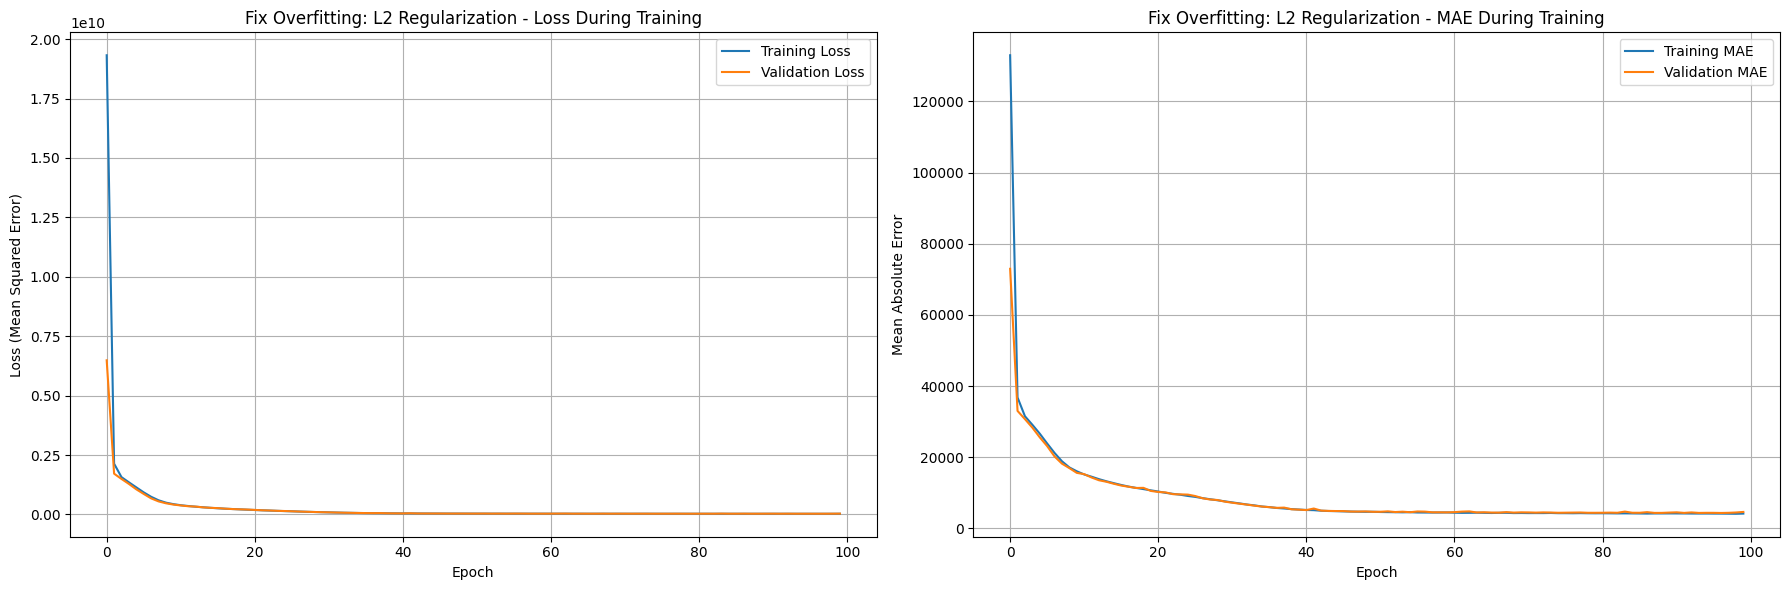

In [64]:
l2_strength = 0.001 # Define the regularization strength

# Create a new complex model with L2 regularization applied to its dense layers
model_l2_regularization = create_model(
    input_shape=X_train_overfit.shape[1], # Use reduced feature set (consistent with baseline overfitting setup)
    num_dense_layers=3,
    neurons_per_layer=[256, 128, 64],
    regularization_type='l2',
    regularization_strength=l2_strength
)

# Train the model with L2 regularization using the reduced training dataset for 100 epochs
history_l2_regularization, loss_l2_regularization, mae_l2_regularization = train_and_evaluate_model(
    model_l2_regularization,
    X_train_overfit, y_train_overfit, # Use reduced training data (consistent with baseline overfitting setup)
    X_val, y_val,
    X_test, y_test,
    epochs=100, # Keep epochs consistent with baseline
    model_name=f"Model with L2 Regularization (lambda={l2_strength})"
)

# Store the results
method_results['l2_regularization'] = {
    'description': f'Fix Overfitting: L2 Regularization (Reduced data, complex model, L2={l2_strength}, many epochs)',
    'history': history_l2_regularization,
    'test_loss': loss_l2_regularization,
    'test_mae': mae_l2_regularization,
    'validation_mae_at_last_epoch': history_l2_regularization.history['val_mean_absolute_error'][-1],
    'training_mae_at_last_epoch': history_l2_regularization.history['mean_absolute_error'][-1],
}

# Plot the training history
plot_history_graphs(history_l2_regularization, "Fix Overfitting: L2 Regularization")

### 4. Fixing Overfitting: Dropout

Dropout is a regularization technique that randomly sets a fraction of input units to 0 at each update during training. This prevents complex co-adaptations on training data, forcing the network to learn more robust features. We'll add Dropout layers to our complex model architecture, again using the *reduced* training dataset, to observe its effect on overfitting.


--- Training Model with Dropout (rate=0.4) ---
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 17623711744.0000 - mean_absolute_error: 124252.2344 - val_loss: 2338588928.0000 - val_mean_absolute_error: 38879.6992
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1982151680.0000 - mean_absolute_error: 35693.2695 - val_loss: 1686770944.0000 - val_mean_absolute_error: 32740.1172
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 1738709248.0000 - mean_absolute_error: 33129.5430 - val_loss: 1418996224.0000 - val_mean_absolute_error: 29899.4629
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 1457024896.0000 - mean_absolute_error: 30363.2129 - val_loss: 1202159232.0000 - val_mean_absolute_error: 27281.4023
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 1193627520.0000 - mean_absolute_error: 27327.5645 - val_loss: 917468224.0000 - val_mean_absolute_error: 23873.5215
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 988570176.0000 - mean_absolute_error: 24618.8535 - val_loss

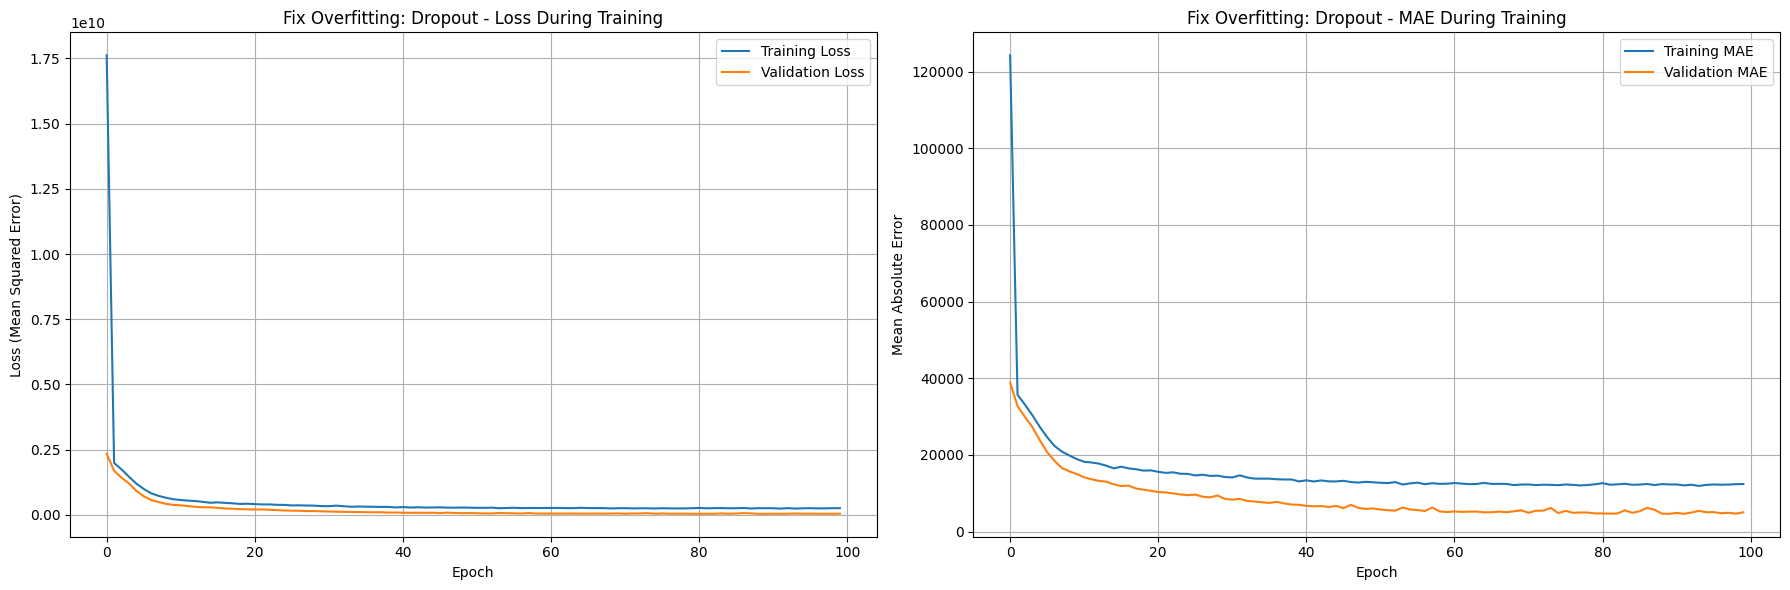

In [65]:
dropout_rate = 0.4 # Define the dropout rate

# Create a new complex model with Dropout layers
model_dropout = create_model(
    input_shape=X_train_overfit.shape[1], # Use reduced feature set (consistent with baseline overfitting setup)
    num_dense_layers=3,
    neurons_per_layer=[256, 128, 64],
    dropout_rate=dropout_rate
)

# Train the model with Dropout using the reduced training dataset for 100 epochs
history_dropout, loss_dropout, mae_dropout = train_and_evaluate_model(
    model_dropout,
    X_train_overfit, y_train_overfit, # Use reduced training data (consistent with baseline overfitting setup)
    X_val, y_val,
    X_test, y_test,
    epochs=100, # Keep epochs consistent with baseline
    model_name=f"Model with Dropout (rate={dropout_rate})"
)

# Store the results
method_results['dropout'] = {
    'description': f'Fix Overfitting: Dropout (Reduced data, complex model, Dropout={dropout_rate}, many epochs)',
    'history': history_dropout,
    'test_loss': loss_dropout,
    'test_mae': mae_dropout,
    'validation_mae_at_last_epoch': history_dropout.history['val_mean_absolute_error'][-1],
    'training_mae_at_last_epoch': history_dropout.history['mean_absolute_error'][-1],
}

# Plot the training history
plot_history_graphs(history_dropout, "Fix Overfitting: Dropout")

### 5. Fixing Overfitting: Early Stopping

Early stopping is a form of regularization that stops training when the performance on a validation dataset starts to degrade, even if the training loss continues to decrease. This prevents the model from learning noise in the training data. We'll use a `EarlyStopping` callback with a `patience` parameter to halt training once the validation loss stops improving, ensuring the model doesn't overfit by training for too many epochs.


--- Training Model with Early Stopping ---
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 19104057344.0000 - mean_absolute_error: 131820.0781 - val_loss: 5770688512.0000 - val_mean_absolute_error: 67896.8203
Epoch 2/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 2029264256.0000 - mean_absolute_error: 35956.3789 - val_loss: 1716963328.0000 - val_mean_absolute_error: 33053.1602
Epoch 3/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1554346496.0000 - mean_absolute_error: 31407.8789 - val_loss: 1469488384.0000 - val_mean_absolute_error: 30436.1680
Epoch 4/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1305469440.0000 - mean_absolute_error: 28564.3770 - val_loss: 1212243968.0000 - val_mean_absolute_error: 27548.2891
Epoch 5/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 1063824064.0000 - mean_absolute_error: 25667.5801 - val_loss: 977384128.0000 - val_mean_absolute_error: 24626.9688
Epoch 6/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 846469888.0000 - mean_absolute_error: 22729.7168 - val_loss

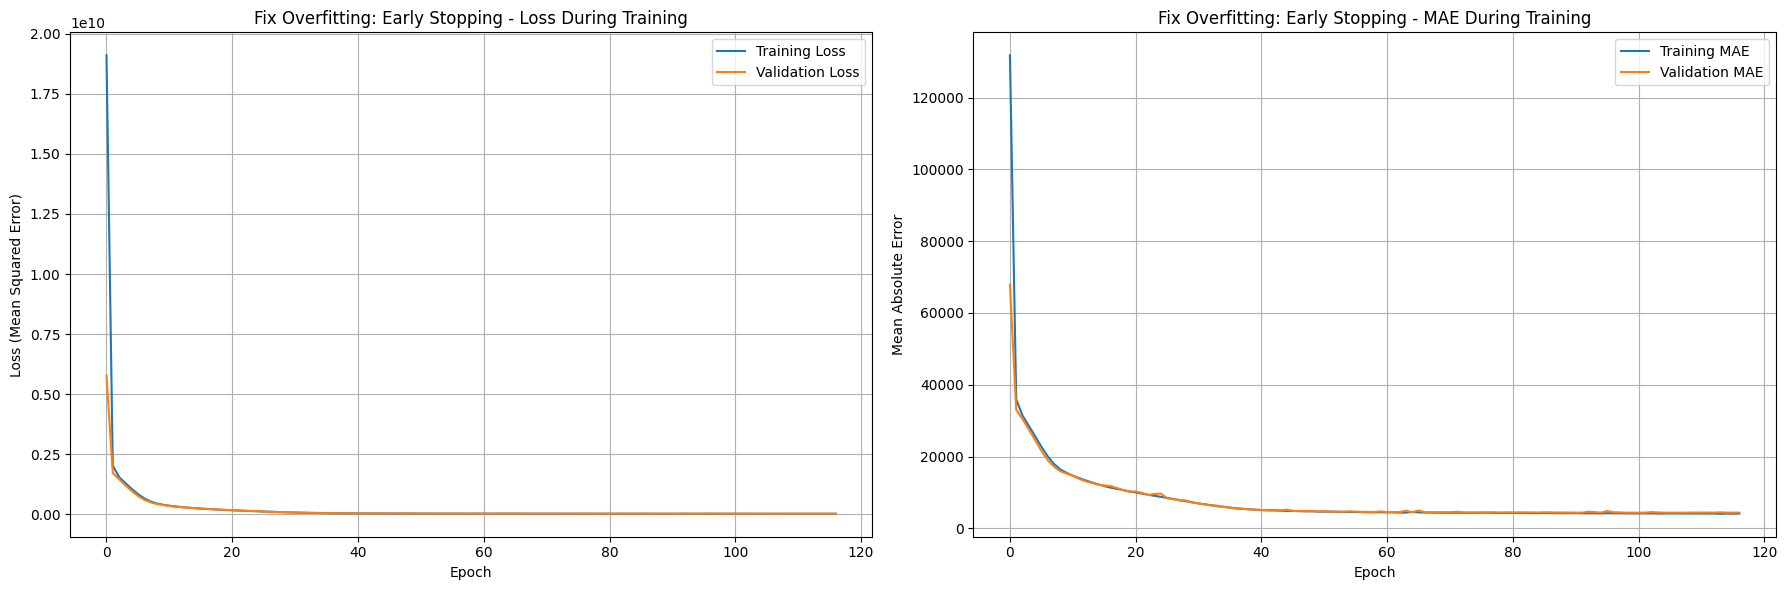

In [66]:
early_stopping_callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',         # Monitor validation loss
    patience=10,                # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True   # Restore model weights from the epoch with the best validation loss
)

# Create a new complex model for early stopping
model_early_stopping = create_model(
    input_shape=X_train_overfit.shape[1], # Use reduced feature set (consistent with baseline overfitting setup)
    num_dense_layers=3,
    neurons_per_layer=[256, 128, 64]
)

# Train the model with Early Stopping. Set a high number of epochs, as the callback will manage the actual stopping point.
history_early_stopping, loss_early_stopping, mae_early_stopping = train_and_evaluate_model(
    model_early_stopping,
    X_train_overfit, y_train_overfit, # Use reduced training data (consistent with baseline overfitting setup)
    X_val, y_val,
    X_test, y_test,
    epochs=200, # A larger number of epochs to allow early stopping to kick in
    model_name="Model with Early Stopping",
    callbacks=[early_stopping_callback]
)

# Store the results
method_results['early_stopping'] = {
    'description': 'Fix Overfitting: Early Stopping (Reduced data, complex model, EarlyStopping callback)',
    'history': history_early_stopping,
    'test_loss': loss_early_stopping,
    'test_mae': mae_early_stopping,
    'validation_mae_at_last_epoch': history_early_stopping.history['val_mean_absolute_error'][-1],
    'training_mae_at_last_epoch': history_early_stopping.history['mean_absolute_error'][-1],
}

# Plot the training history
plot_history_graphs(history_early_stopping, "Fix Overfitting: Early Stopping")

### 6. Fixing Overfitting: Feature Selection

Using too many irrelevant or redundant features can lead to overfitting, as the model might learn to associate noise in specific features with the target variable. By selecting only the most important features, we can simplify the input space and encourage the model to focus on genuinely predictive patterns. We'll use a pre-defined subset of features (`selected_features`) from the notebook's earlier underfitting phase, along with the complex model architecture and *reduced* training dataset, to see how feature selection impacts overfitting.


--- Training Model with Feature Selection ---
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 18371530752.0000 - mean_absolute_error: 128386.8828 - val_loss: 4268332800.0000 - val_mean_absolute_error: 55917.1875
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 2269254656.0000 - mean_absolute_error: 38330.6641 - val_loss: 2165026048.0000 - val_mean_absolute_error: 37339.5156
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 2068701824.0000 - mean_absolute_error: 36536.6211 - val_loss: 2065200128.0000 - val_mean_absolute_error: 36402.6602
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1973448704.0000 - mean_absolute_error: 35612.0703 - val_loss: 1989408768.0000 - val_mean_absolute_error: 35657.7266
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1895807616.0000 - mean_absolute_error: 34815.3203 - val_loss: 1895933696.0000 - val_mean_absolute_error: 34765.7109
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 1819083008.0000 - mean_absolute_error: 34033.9844 - val_lo

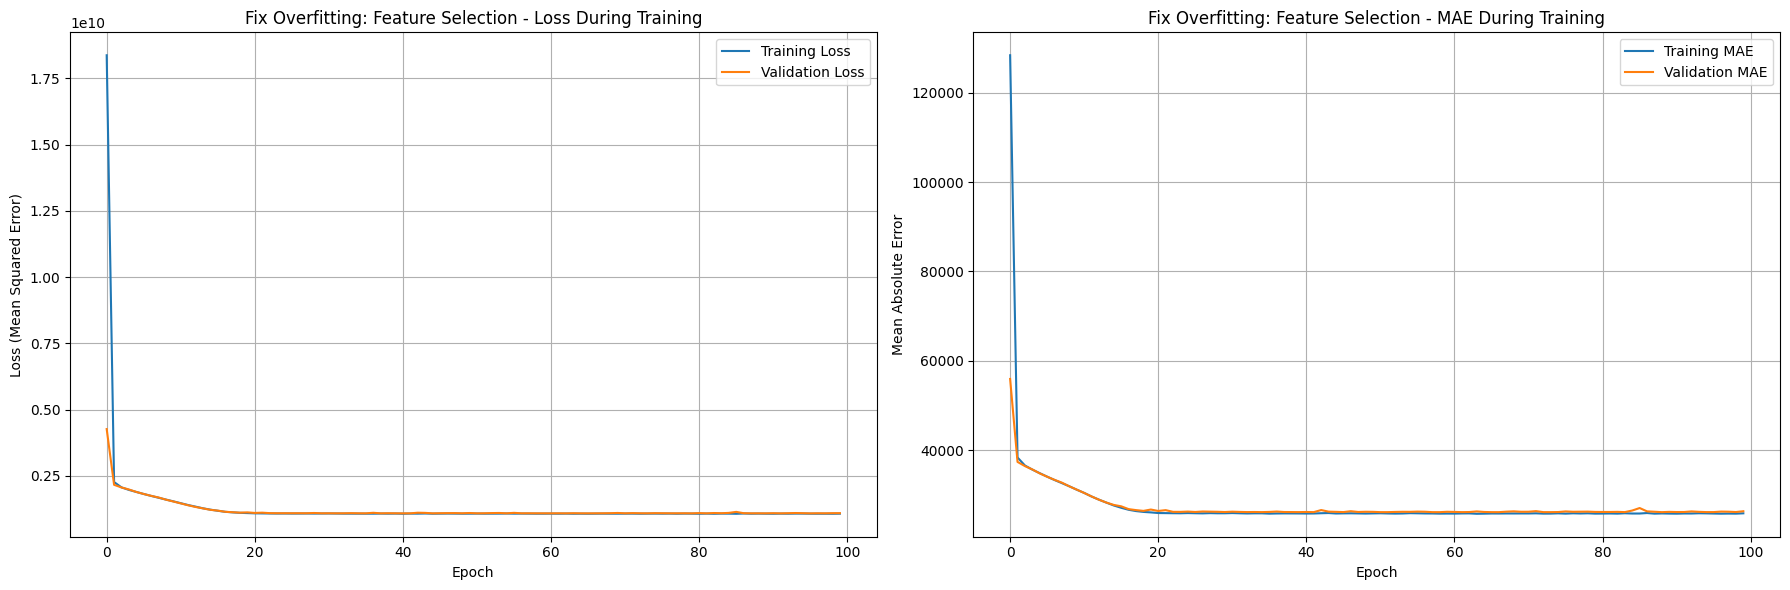

In [67]:
# Use the pre-defined 'selected_features' from the notebook's underfitting phase.
# These features are: ['experience_years', 'skills_count', 'certifications', 'job_title_Software Engineer', 'remote_work_Yes']

# Prepare the datasets with only the selected features
X_train_overfit_selected = X_train_overfit[selected_features].astype('float32')
y_train_overfit_selected = y_train_overfit # y_train_overfit remains unchanged
X_val_selected = X_val[selected_features].astype('float32')
y_val_selected = y_val # y_val remains unchanged
X_test_selected = X_test[selected_features].astype('float32')
y_test_selected = y_test # y_test remains unchanged

# Create a new complex model, adjusting input_shape for selected features
model_feature_selection = create_model(
    input_shape=X_train_overfit_selected.shape[1], # Input shape changes due to feature selection
    num_dense_layers=3,
    neurons_per_layer=[256, 128, 64]
)

# Train the model with selected features using the reduced training dataset for 100 epochs
history_feature_selection, loss_feature_selection, mae_feature_selection = train_and_evaluate_model(
    model_feature_selection,
    X_train_overfit_selected, y_train_overfit_selected, # Use reduced training data with selected features
    X_val_selected, y_val_selected,
    X_test_selected, y_test_selected,
    epochs=100, # Keep epochs consistent with baseline
    model_name="Model with Feature Selection"
)

# Store the results
method_results['feature_selection'] = {
    'description': 'Fix Overfitting: Feature Selection (Reduced data, selected features, complex model, many epochs)',
    'history': history_feature_selection,
    'test_loss': loss_feature_selection,
    'test_mae': mae_feature_selection,
    'validation_mae_at_last_epoch': history_feature_selection.history['val_mean_absolute_error'][-1],
    'training_mae_at_last_epoch': history_feature_selection.history['mean_absolute_error'][-1],
}

# Plot the training history
plot_history_graphs(history_feature_selection, "Fix Overfitting: Feature Selection")

### Final Comparison of Overfitting Fix Techniques

Now that we've applied each technique individually, let's visualize and compare their effectiveness in reducing overfitting. The bar chart below will display the validation Mean Absolute Error (MAE) for each method at the last epoch, allowing us to identify which technique yielded the best generalization performance.

/tmp/ipykernel_3143/697907192.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Technique', y='Validation MAE', data=comparison_df, palette='viridis')


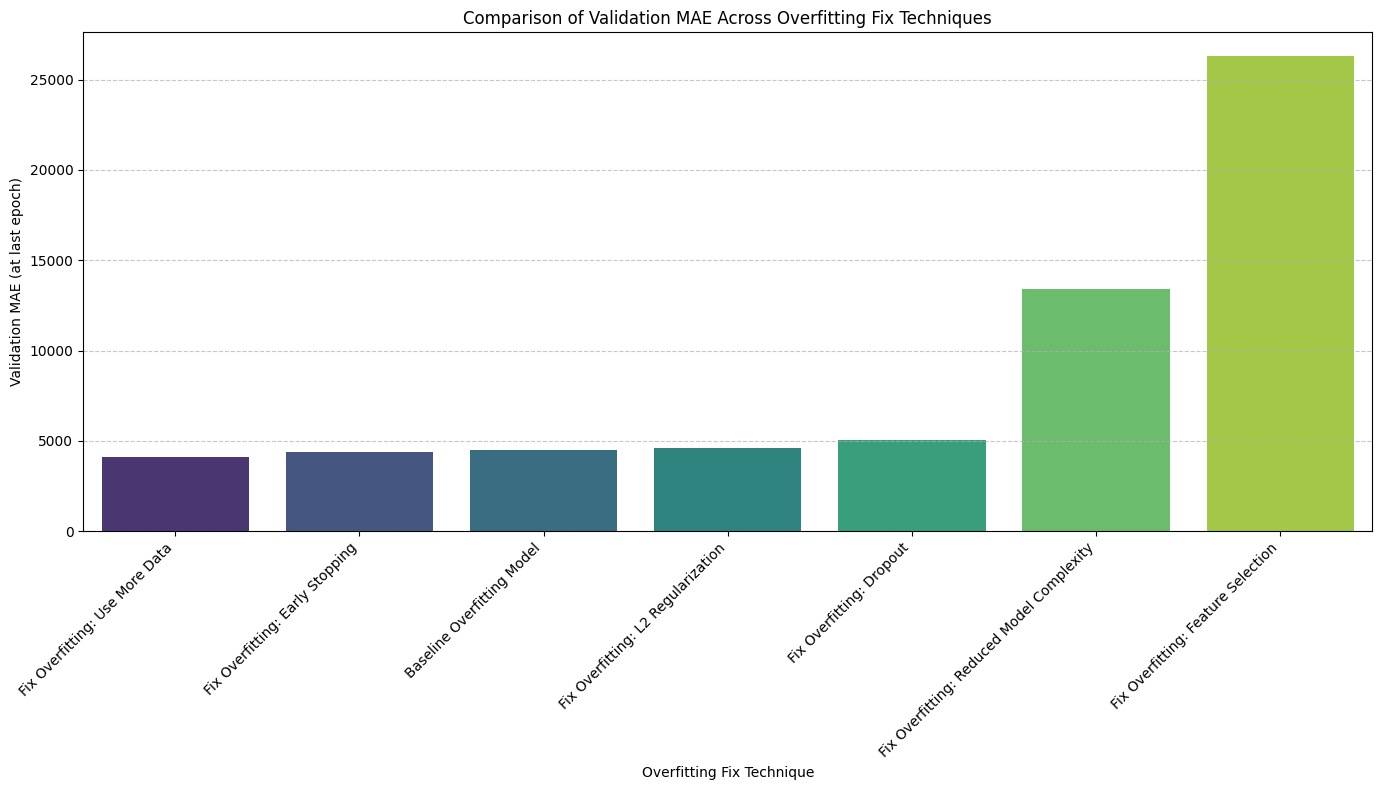


--- Numerical Summary of Results (Validation MAE at Last Epoch) ---
- Fix Overfitting: Use More Data: 4096.71
- Fix Overfitting: Early Stopping: 4357.90
- Baseline Overfitting Model: 4508.75
- Fix Overfitting: L2 Regularization: 4629.98
- Fix Overfitting: Dropout: 5039.55
- Fix Overfitting: Reduced Model Complexity: 13405.68
- Fix Overfitting: Feature Selection: 26298.64


In [68]:
plt.figure(figsize=(14, 8))

# Extract method names and their final validation MAEs
method_names = [result['description'].split('(')[0].strip() for result in method_results.values()]
validation_maes = [result['validation_mae_at_last_epoch'] for result in method_results.values()]

# Create a DataFrame for easier plotting and sorting
comparison_df = pd.DataFrame({
    'Technique': method_names,
    'Validation MAE': validation_maes
})

# Sort the DataFrame by Validation MAE for better visualization (lowest MAE is best)
comparison_df = comparison_df.sort_values(by='Validation MAE', ascending=True)

sns.barplot(x='Technique', y='Validation MAE', data=comparison_df, palette='viridis')
plt.title('Comparison of Validation MAE Across Overfitting Fix Techniques')
plt.xlabel('Overfitting Fix Technique')
plt.ylabel('Validation MAE (at last epoch)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print a numerical summary of the results
print("\n--- Numerical Summary of Results (Validation MAE at Last Epoch) ---")
for index, row in comparison_df.iterrows():
    print(f"- {row['Technique']}: {row['Validation MAE']:.2f}")